In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from torchvision import datasets, models
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import timm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Full Evaluation Suite on: {device}")

EMOTION_MAP = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}
target_names = [EMOTION_MAP[i] for i in range(7)]

Executing Full Evaluation Suite on: cuda


In [2]:
!unzip -q archive.zip

In [3]:
# scaling eval set
eval_transforms = v2.Compose([
    v2.Resize((224, 224), antialias=True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Mapping kaggle to normal indices
folder_to_csv_mapping = {
    0: 0, # angry -> Angry
    1: 1, # disgust -> Disgust
    2: 2, # fear -> Fear
    3: 3, # happy -> Happy
    4: 6, # neutral -> Neutral
    5: 4, # sad -> Sad
    6: 5  # surprise -> Surprise
}

def target_aligner(target):
    return folder_to_csv_mapping[target]

# Loading
test_dir = '/content/train'

full_test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=eval_transforms,
    target_transform=target_aligner
)

test_loader = DataLoader(full_test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Successfully mapped {len(full_test_dataset)} raw images from {test_dir}.")

Successfully mapped 28709 raw images from /content/train.


In [4]:
# Redefining the Architectures
class TargetedViT(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=num_classes)
    def forward(self, x):
        return self.backbone(x)

class EfficientFER(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

In [5]:
# Instantiate and push to GPU
vit_model = TargetedViT(num_classes=7).to(device)
cnn_model = EfficientFER(num_classes=7).to(device)

# Load the optimized weights
vit_model.load_state_dict(torch.load('vit_targeted.pth', map_location=device))
cnn_model.load_state_dict(torch.load('efficientnet_fer_sota.pth', map_location=device))

vit_model.eval()
cnn_model.eval()
print("Weights successfully loaded into memory.")

Weights successfully loaded into memory.


In [6]:
# Inference
true_labels = []
preds_vit = []
preds_cnn = []
preds_ensemble = []

In [7]:
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)

        # Ground Truth
        true_labels.extend(labels.cpu().numpy())

        # Raw Logits
        logits_vit = vit_model(images)
        logits_cnn = cnn_model(images)

        # Individual Model Predictions
        preds_vit.extend(torch.argmax(logits_vit, dim=1).cpu().numpy())
        preds_cnn.extend(torch.argmax(logits_cnn, dim=1).cpu().numpy())

        # Ensemble Prediction (Softmax Averaging)
        prob_vit = F.softmax(logits_vit, dim=1)
        prob_cnn = F.softmax(logits_cnn, dim=1)
        ensemble_prob = (prob_vit + prob_cnn) / 2.0

        preds_ensemble.extend(torch.argmax(ensemble_prob, dim=1).cpu().numpy())

true_labels = np.array(true_labels)
preds_vit = np.array(preds_vit)
preds_cnn = np.array(preds_cnn)
preds_ensemble = np.array(preds_ensemble)

100%|██████████| 449/449 [06:02<00:00,  1.24it/s]


MODEL METRICS
Targeted ViT-B/16 Accuracy: 0.6669
EfficientNet-B0 Accuracy:   0.5625
ENSEMBLE METRICS
Ensemble Accuracy:          0.6748

ENSEMBLE CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Angry       0.62      0.58      0.60      3995
     Disgust       0.86      0.35      0.49       436
        Fear       0.58      0.43      0.49      4097
       Happy       0.85      0.87      0.86      7215
         Sad       0.56      0.59      0.57      4830
    Surprise       0.72      0.79      0.75      3171
     Neutral       0.60      0.71      0.65      4965

    accuracy                           0.67     28709
   macro avg       0.68      0.62      0.63     28709
weighted avg       0.67      0.67      0.67     28709



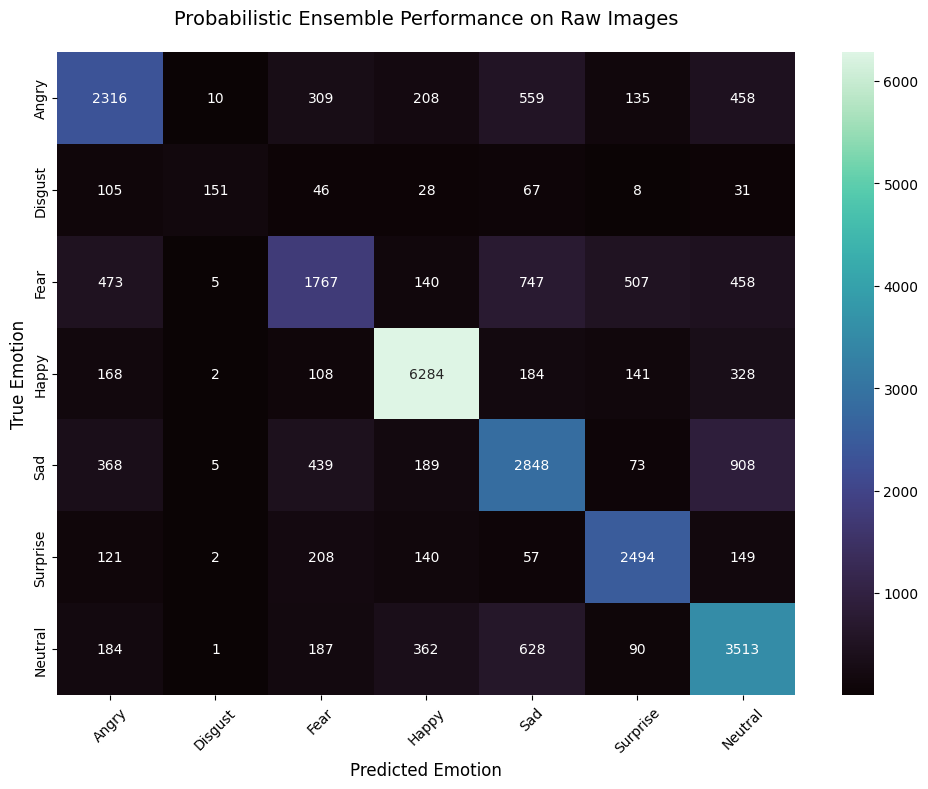

In [8]:
print("MODEL METRICS")
print(f"Targeted ViT-B/16 Accuracy: {accuracy_score(true_labels, preds_vit):.4f}")
print(f"EfficientNet-B0 Accuracy:   {accuracy_score(true_labels, preds_cnn):.4f}")


print("ENSEMBLE METRICS")
print(f"Ensemble Accuracy:          {accuracy_score(true_labels, preds_ensemble):.4f}\n")

print("ENSEMBLE CLASSIFICATION REPORT")
print(classification_report(true_labels, preds_ensemble, target_names=target_names))

# Plot Confusion Matrix
cm = confusion_matrix(true_labels, preds_ensemble)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako', xticklabels=target_names, yticklabels=target_names)
plt.title('Probabilistic Ensemble Performance on Raw Images', pad=20, fontsize=14)
plt.ylabel('True Emotion', fontsize=12)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()